# Least squares regression

---

#### Summary videos

- [Fitting a line with least squares regression](https://youtu.be/z8DmwG2G4Qc?si=bsNXI6shdY_MONN2) (7 minutes)
- [Section 8.2 overview by an author of the textbook](https://youtu.be/yqf0L_WEaW0?si=ZrZoKW_AmpJmqsYO) (44 minutes)

#### Walkthrough videos

- [Least squares regression line](https://drive.google.com/file/d/12s7Z90VMweEom2SRXiwFUwd-eeYECWVE/view?usp=sharing) (9 minutes)
- [Finding the least squares regression line](https://drive.google.com/file/d/1gvcL7XiuoUxu51OXZ2NrBdRJ-gC8kZiS/view?usp=sharing) (9 minutes)
- [Interpreting a regression model](https://drive.google.com/file/d/1nbfs2mGCbY4Usk9zVroZGmuE0RuJw4Hk/view?usp=sharing) (11 minutes)
- [Categorical predictors](https://drive.google.com/file/d/1BT260LwKHrHdY6dIQUQGk8RQnty-S3zz/view?usp=sharing) (11 minutes)
- [A Python function](https://drive.google.com/file/d/18ic61ve9VYAfyvTJ52qImKf2ryILBMYw/view?usp=sharing) (3 minutes)

---

Consider the `possums` data set again.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from plotnine import *

possums = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/refs/heads/main/possum.csv')

(
  ggplot(possums, aes(x='total_l', y='head_l')) +
  geom_point() +
  geom_smooth(method='lm')
)

We can think of the linear model as the "line of best fit" --- but what does "best" mean exactly? In situations like this, we may like to think of "best" as meaning

> resulting in the smallest possible error.

Recall, the error between observed and predicted in this case is called the *residual*. So, we may try to find the line that somehow minimizes the magnitude of the sum of the residuals (resulting in the smallest collective error).

This is possible, but more common is something called the **least squares regression line** which minimizes the sum of the *squares* of the residuals instead of the sum of of the *magnitudes* of the residuals.

## Conditions for the least squares regression line

In order for the least squares regression line to be a reasonable model we need to satisfy the following conditions.

- **Linearity.** The data should follow a linear trend.

- **Nearly normal residuals.** The residuals should be nearly normal without extreme outliers.

- **Constant variability.** The variability of points around the regression line should be roughly constant.

- **Independent observations.** As usual, we need observations to be independent (e.g., from a random sample). Be careful in this case of *time series data* --- this sort of data usually requires some extra care when modeling because observations may not be independent (or may otherwise have some additional structure).

### Exercise
Below is a figure from page 319 of the textbook. For each pair of plots, identify which one of the conditions above fails.

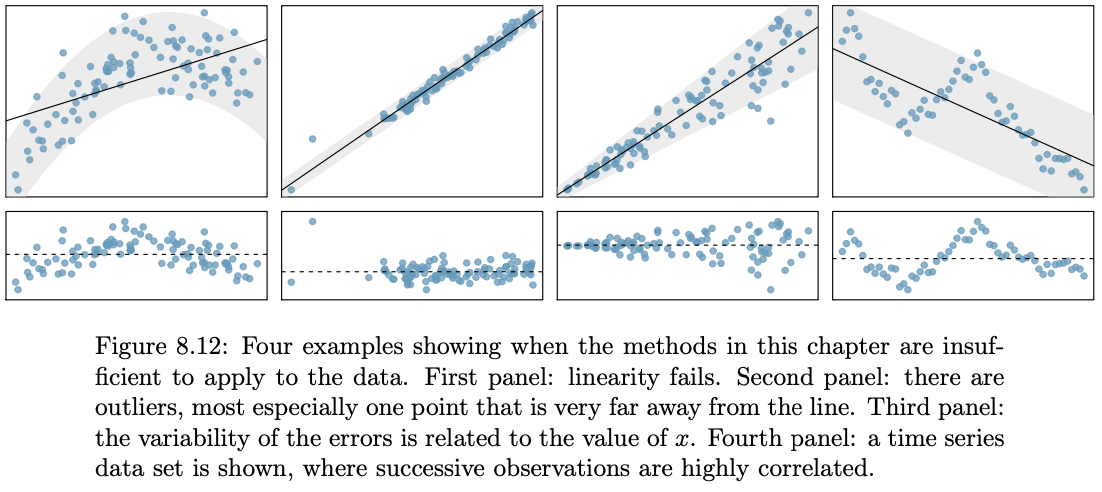

## Finding the least squares line

The least squares regression line can be approximated using the $R$ value and some summary statistics from the data.

In [ ]:
# Correlation coefficients

possums[['age', 'head_l', 'skull_w', 'total_l', 'tail_l']].corr()

The correlation table tells us the $R \approx 0.69$ between `head_l` and `total_l`. By nature of the definition of $R$, the slope of the least squares regression model is approximately

$$ b_1 = \frac{s_y}{s_x} R.$$

### Exercise

- Using the numerical summary below, determine $b_1$.

In [ ]:
# Numerical summaries of the variables in `possums`

possums[['age', 'head_l', 'skull_w', 'total_l', 'tail_l']].describe()

- As it turns out, the point $(\bar{x}, \bar{y})$ is *always* on the least squares regression line. Why do you think that is?
- Use this information along with the point-slope form of a line to write an equation for the least squares regression line as $\hat{y} = b_0 + b_1 x$.

## Interpreting regression model parameter estimates

Compare our result in the previous section to the model fitted with the code below.

In [ ]:
# Import the `statsmodels` library
import statsmodels.api as sm

# Set the formula string (which variables to compare) and the dataframe to use
formula_string = "head_l ~ total_l"
dataframe = possums

# Fit the linear model
model = sm.formula.ols(formula = formula_string, data = dataframe)
model_fitted = model.fit()

# Print the results
print(model_fitted.summary())

### Exercises

- For each 1 cm increase in total length of a possum, how much would you expect the head length to change?
- Does the vertical intercept make sense in this model?
- Note, the model summary above states `R-squared` to be about 0.478. Use this to find $R$.
  - How do you know if $R$ should be positive or negative?
- $R^2$ describes the amount of variation in the response variable that is explained
by the least squares line. Interpret the value $R^2$ for this model in context.

## Categorical predictors with two levels

A categorical variable with two levels can also sometimes be useful as an explanatory (or predictor variable) in linear regression.

In [ ]:
(
  ggplot(possums) +
  aes(x = 'sex', y = 'head_l') +
  geom_point()
)

To incorporate the categorical variable `sex` into the regression equations, we can create an **indicator variable**, which is a numerical representation of the variable. We can make a new variable `sex_f` that takes a value of 1 if the sex is female and 0 if the sex is male.

In [ ]:
possums['sex_f'] = possums['sex'].map({'m': 0, 'f': 1})

In [ ]:
possums.head()

In [ ]:
(
  ggplot(possums) +
  aes(x = 'sex_f', y = 'head_l') +
  geom_point() +
  geom_smooth(method = 'lm', se = False)
)

In [ ]:
# Import the `statsmodels` library
import statsmodels.api as sm

# Set the formula string (which variables to compare) and the dataframe to use
formula_string = "head_l ~ sex_f"
dataframe = possums

# Fit the linear model
model = sm.formula.ols(formula = formula_string, data = dataframe)
model_fitted = model.fit()

# Print the results
print(model_fitted.summary())

### Exercises

- Use the model summary to write an equation for the least squares regression line.
- Interpret the slope and intercept of the least squares regression line in context.
- How much variation in possum head length appears to be explained by sex?
- You may notice that the model produces a $t$-statistic and a p-value. Based on the p-value, do you think there is strong enough evidence to conclude that sex is predictive of possum head length?

## A Python function for least squares regression

Below is some code for a function that you can use to perform linear regression quickly in Python.

In [ ]:
# This function takes a dataframe along with predictor and response variable and fits the least
# squares regression model.
import statsmodels.api as sm

def least_squares_regression(data, response_variable, predictor_variable):
  formula_string = response_variable + " ~ " + predictor_variable
  model = sm.formula.ols(formula = formula_string, data = data)
  model_fitted = model.fit()

  print(model_fitted.summary())
  return model_fitted

Try using it to reproduce the regression outputs from earlier.

In [ ]:
least_squares_regression(possums, 'head_l', 'total_l')

In [ ]:
least_squares_regression(possums, 'head_l', 'sex_f')

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.